<a href="https://colab.research.google.com/github/SimbakNetmind/series-de-tiempo/blob/M%C3%A9todos_para_Pron%C3%B3stico_y_Anal%C3%ADtica-Avanzada/03_M%C3%A9todos_de_suavizado_(EMA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos de Suavizado: Media Móvil Exponencial (EMA)

---

### Descripción
La **Media Móvil Exponencial (EMA)** es la base del **Suavizamiento Exponencial Simple (SES)**. Sus principales características son:

* **Pesos dinámicos:** Asigna pesos que decrecen exponencialmente conforme los datos son más antiguos.
* **Influencia total:** Todos los datos de la serie influyen en el cálculo, pero los más recientes tienen un peso mucho mayor.

---

### Definición Matemática

La fórmula para obtener el valor suavizado es:

$$S_t = \alpha y_t + (1 - \alpha)S_{t-1}$$

**Donde:**
* $S_t$: Valor suavizado en el momento actual.
* $y_t$: Observación real en el momento actual.
* $S_{t-1}$: Valor suavizado del periodo anterior.
* $\alpha$ (Alfa): Parámetro de suavizamiento ($0 < \alpha < 1$).

---

### ¿Cómo interpretar el parámetro $\alpha$?

> * **$\alpha$ cercano a 1:** Da mucha importancia a los datos más recientes. El suavizado reacciona rápido a los cambios, pero elimina poco ruido.
> * **$\alpha$ cercano a 0:** Da mucha importancia a la historia pasada. El resultado es una línea muy suave que ignora fluctuaciones rápidas.

---
# Ejemplo Práctico: Media Móvil Exponencial (EMA)

El valor suavizado actual ($S_t$) se obtiene mediante una **definición recursiva**, combinando el dato real del momento con el resultado del suavizado anterior.

---

### Configuración del Ejemplo
* **Fórmula:** $S_t = \alpha y_t + (1 - \alpha)S_{t-1}$
* **Parámetro de suavizado ($\alpha$):** $0.3$
* **Factor de persistencia ($1 - \alpha$):** $0.7$

---

### Tabla de Cálculos ($t = 1$ al $10$)

| Tiempo ($t$) | Dato Real ($y_t$) | Cálculo ($0.3 \cdot y_t + 0.7 \cdot S_{t-1}$) | EMA ($S_t$) |
| :--- | :--- | :--- | :--- |
| 1 | 10 | **Valor Inicial** | **10** |
| 2 | 12 | 0.3(12) + 0.7(10) | 10.6 |
| 3 | 13 | 0.3(13) + 0.7(10.6) | 11.32 |
| 4 | 16 | 0.3(16) + 0.7(11.32)| 12.72 |
| 5 | 15 | 0.3(15) + 0.7(12.72) | 13.4 |
| 6 | 20 | 0.3(20) + 0.7(13.4) | 15.39 |
| 7 | 22 | 0.3(22) + 0.7(15.39) | 17.37 |
| 8 | 21 | 0.3(21) + 0.7(17.37) | 18.46 |
| 9 | 23 | 0.3(23) + 0.7(18.46) | 19.82 |
| 10 | 25 |0.3(25) + 0.7(19.82) | 21.37 |
| 11 | 26 | 0.3(26) + 0.7(21.37) | 22.76 |
| 12 | 28 | 0.3(28) + 0.7(22.76) | 24.33 |
| 13 | 30 | 0.3(30) + 0.7(24.33) | 26.03 |
| 14 | 29 | 0.3(29) + 0.7(26.03) | 26.92 |
| 15 | 31 | 0.3(31) + 0.7(26.92) | 28.14 |
| 16 | 33 | 0.3(33) + 0.7(28.15) | 29.61 |
| 17 | 35 | 0.3(35) + 0.7(29.61) | 31.22 |
| 18 | 36 | 0.3(36) + 0.7(31.22) | 32.65 |
| 19 | 38 | 0.3(38) + 0.7(32.65) | 34.26 |
| 20 | 42 | 0.3(42) + 0.7(34.26) | 36.58 |

---

### Observaciones Clave
1. **Punto de partida:** En el tiempo $t=1$, no existe un valor anterior ($S_{t-1}$), por lo que se toma el primer dato real como el valor inicial del EMA.
2. **Efecto de arrastre:** Nota cómo el valor del tiempo 10 ($21.37$) depende indirectamente de todos los valores anteriores a través de $S_{t-1}$.
3. **Suavizado:** Si comparas la columna **Dato Real** con la columna **EMA**, verás que el EMA sube de forma más constante y menos "brusca" que los datos originales.

---
# Perspectiva de Pesos Exponenciales (EMA)

Esta tabla demuestra que el valor suavizado final es en realidad una **suma ponderada** de todas las observaciones pasadas. Los pesos disminuyen geométricamente a medida que el dato es más antiguo.

---

### Configuración del Análisis
* **Fórmula del Factor (Peso):** $\alpha(1 - \alpha)^k$
* **Donde $k$:** Es la distancia temporal respecto al presente ($k=0$ para el dato más reciente).
* **$\alpha$:** $0.3$

---

### Tabla de Descomposición de Pesos ($t = 1$ al $20$)

| Tiempo ($t$) | Dato ($y_t$) | Factor de Peso $\alpha(1-\alpha)^k$ | Contribución (Factor * $y_t$) |
| :--- | :--- | :--- | :--- |
| 1 | 10 | 0.000342 | 0.003419669 |
| 2 | 12 | 0.000489 | 0.005862289 |
| 3 | 13 | 0.000698 | 0.00907259 |
| 4 | 16 | 0.000997 | 0.015951807 |
| 5 | 15 | 0.001424 | 0.021364027 |
| 6 | 20 | 0.002035 | 0.040693384 |
| 7 | 22 | 0.002907 | 0.063946747 |
| 8 | 21 | 0.004152 | 0.087200109 |
| 9 | 23 | 0.005932 | 0.136435545 |
| 10 | 25 | 0.008474 | 0.211856437 |
| 11 | 26 | 0.012106 | 0.314758135 |
| 12 | 28 | 0.017294 | 0.484243284 |
| 13 | 30 | 0.024706 | 0.7411887 |
| 14 | 29 | 0.035295 | 1.0235463 |
| 15 | 31 | 0.050421 | 1.563051 |
| 16 | 33 | 0.07203 | 2.37699 |
| 17 | 35 | 0.1029 | 3.6015 |
| 18 | 36 | 0.147 | 5.292 |
| 19 | 38 | 0.21 | 7.98 |
| 20 | 42 | 0.3 | 12.6 |

---

### Resultado Final
**Suma de todas las contribuciones:** $$\sum (\text{Factor} \cdot y_t) = \mathbf{36.57308002}$$

### Conclusión Visual
Observa que el dato más reciente ($t=20$) aporta **12.6** al total, mientras que el primer dato ($t=1$) apenas aporta **0.0034**. Esto confirma que en el EMA:
1. El pasado nunca se olvida del todo (todos los datos suman algo).
2. El presente domina la tendencia (el 30% del valor final viene solo del último

---
# Análisis del Parámetro de Suavizado ($\alpha$)

En este modelo, el valor de **$\alpha = 0.3$** es la constante que define qué tanta importancia le damos a la información reciente frente a la histórica.

### 1. ¿Cómo se distribuye el peso?
El peso que cada dato aporta al resultado final se calcula con la fórmula:
$$\text{Peso} = \alpha(1 - \alpha)^k$$
Donde $k$ es la distancia (en pasos de tiempo) desde el dato actual hacia atrás.

* **Dato Actual ($t=20$):** Tiene el peso máximo de **0.3** (30% de influencia).
* **Dato Anterior ($t=19$):** Su peso es $0.3 \times 0.7 = \mathbf{0.21}$ (21% de influencia).
* **Dato Tras-anterior ($t=18$):** Su peso es $0.3 \times 0.7^2 = \mathbf{0.147}$ (14.7% de influencia).

### 2. Comportamiento del Suavizado
Al usar $\alpha = 0.3$, estamos eligiendo un equilibrio:
* **Retención:** Conservamos el **70%** de la inercia del pasado.
* **Actualización:** Incorporamos un **30%** del valor nuevo.

> **Regla de oro:** > * Si subes $\alpha$ (ej. 0.8), la línea seguirá los puntos reales casi exactos (mucho ruido).
> * Si bajas $\alpha$ (ej. 0.1), la línea será casi plana (reacciona muy lento a los cambios).

---

### Verificación del Resultado Final
El valor **36.57** que ves al final de la tabla es la suma de multiplicar cada dato real ($y_t$) por su factor de peso correspondiente. Es una **suma ponderada exponencial**:

$$\text{EMA}_{20} = \sum_{t=1}^{20} [y_t \cdot \text{Factor}_t]$$

---
## 📗 ***Instalación bibliotecas***

In [ ]:
!pip install numpy -q
!pip install pandas -q
!pip install matplotlib -q

## 🎯 ***Práctica codigo (EMA)***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Datos
data = [10, 12, 13, 16, 15, 20, 22, 21, 23, 25,
        26, 28, 30, 29, 31, 33, 35, 36, 38, 42]

df = pd.DataFrame({
    'Tiempo (t)': range(1, len(data) + 1),
    'Dato (yt)': data
})

# 2. Configuración EMA
alpha = 0.3
ema_values = []
calculation_strings = []

# Initialize S_t-1
S_prev = None

for i in range(len(data)):
    y_t = data[i]

    if i == 0:
        S_t = float(y_t) # Ensure it's float for consistency later
        calculation_strings.append("**Valor Inicial**")
    else:
        S_t = alpha * y_t + (1 - alpha) * S_prev
        # Format to match markdown: 0.3(12) + 0.7(10) or 0.3(13) + 0.7(10.6)
        # S_prev for the calculation string should be formatted as it appears in the EMA column from previous step
        s_prev_str = f"{S_prev:.0f}" if S_prev == int(S_prev) else f"{S_prev:.2f}"
        calculation_strings.append(f"{alpha:.1f}({y_t}) + {1-alpha:.1f}({s_prev_str})")

    ema_values.append(S_t)
    S_prev = S_t # Update S_prev for the next iteration

# Format EMA column based on markdown: first value integer, others two decimals
formatted_ema_values = []
for i, val in enumerate(ema_values):
    if i == 0:
        formatted_ema_values.append(f"{val:.0f}")
    else:
        formatted_ema_values.append(f"{val:.2f}")

df['Cálculo (0.3 * yt + 0.7 * St-1)'] = calculation_strings
df['EMA (St)'] = formatted_ema_values

# Opción A: Usar to_string con col_space (Define el ancho mínimo de cada columna)
print(df.to_string(index=False, col_space=15, justify='center'))

   Tiempo (t)       Dato (yt)   Cálculo (0.3 * yt + 0.7 * St-1)     EMA (St)   
        1              10                **Valor Inicial**              10     
        2              12                0.3(12) + 0.7(10)           10.60     
        3              13             0.3(13) + 0.7(10.60)           11.32     
        4              16             0.3(16) + 0.7(11.32)           12.72     
        5              15             0.3(15) + 0.7(12.72)           13.41     
        6              20             0.3(20) + 0.7(13.41)           15.38     
        7              22             0.3(22) + 0.7(15.38)           17.37     
        8              21             0.3(21) + 0.7(17.37)           18.46     
        9              23             0.3(23) + 0.7(18.46)           19.82     
       10              25             0.3(25) + 0.7(19.82)           21.37     
       11              26             0.3(26) + 0.7(21.37)           22.76     
       12              28             0.

## ⚖ ***Tabla para pesos  (EMA)***

In [2]:
# 3. Perspectiva de Pesos Exponenciales (EMA)

# Obtener los datos y alpha del DataFrame existente
data_weights = df['Dato (yt)'].tolist()
alpha_weights = alpha # Alpha ya está definido como 0.3

# Calcular los pesos y contribuciones
weights_factors = []
contributions = []

# El 'k' en la fórmula α(1-α)^k es la distancia temporal respecto al presente.
# Para el dato más reciente, k=0, para el anterior k=1, etc.
# En nuestra iteración, `i` va de 0 a 19, que representa el tiempo de 1 a 20.
# Para calcular k, necesitamos la distancia al último elemento (len(data)-1).
# Entonces, k = (len(data) - 1) - i

for i in range(len(data_weights)):
    y_t = data_weights[i]
    k_value = (len(data_weights) - 1) - i # Distancia temporal al presente (dato más reciente)

    # Factor de Peso: α(1-α)^k
    if i == (len(data_weights) - 1):
        # Para el último dato (k=0), el factor es solo alpha
        factor = alpha_weights
    else:
        factor = alpha_weights * (1 - alpha_weights)**k_value
    weights_factors.append(factor)

    # Contribución (Factor * y_t)
    contribution = factor * y_t
    contributions.append(contribution)

# Crear un DataFrame para la tabla de descomposición de pesos
df_weights = pd.DataFrame({
    'Tiempo (t)': range(1, len(data_weights) + 1),
    'Dato (yt)': data_weights,
    'Factor de Peso α(1-α)^k': [f'{f:.6f}' for f in weights_factors],
    'Contribución (Factor * yt)': [f'{c:.9f}' for c in contributions]
})

# Invertir el DataFrame para que el dato más antiguo esté arriba (t=1)
df_weights_reversed = df_weights.iloc[::-1].reset_index(drop=True)

# Suma de todas las contribuciones
sum_contributions = sum(contributions)

print(df_weights_reversed.to_string(index=False, col_space=15, justify='center'))
print(f"\nSuma de todas las contribuciones: {sum_contributions:.9f}")

   Tiempo (t)       Dato (yt)   Factor de Peso α(1-α)^k Contribución (Factor * yt)
       20              42               0.300000               12.600000000       
       19              38               0.210000                7.980000000       
       18              36               0.147000                5.292000000       
       17              35               0.102900                3.601500000       
       16              33               0.072030                2.376990000       
       15              31               0.050421                1.563051000       
       14              29               0.035295                1.023546300       
       13              30               0.024706                0.741188700       
       12              28               0.017294                0.484243284       
       11              26               0.012106                0.314758135       
       10              25               0.008474                0.211856437       
    

---
## 📈 ***Grafica serie EMA vs Dato Reales***

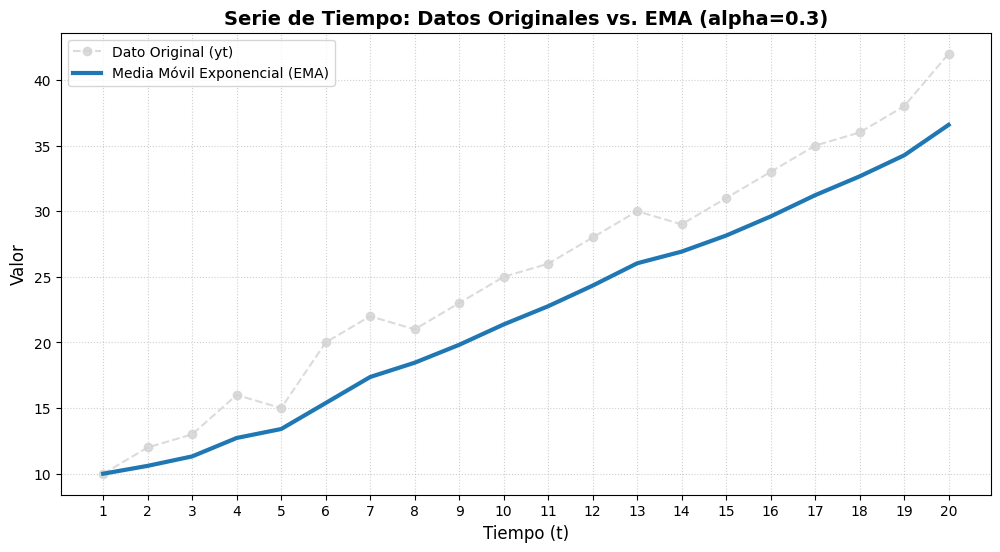

In [3]:
# 1. Configurar el tamaño de la gráfica
plt.figure(figsize=(12, 6))

# 2. Graficar Datos Originales (Puntos y línea gris)
plt.plot(df['Tiempo (t)'], df['Dato (yt)'],
         label='Dato Original (yt)',
         marker='o',
         linestyle='--',
         color='lightgray',
         alpha=0.8)

# 3. Graficar EMA (Línea azul sólida)
plt.plot(df['Tiempo (t)'], ema_values,
         label='Media Móvil Exponencial (EMA)',
         color='#1f77b4',
         linewidth=3)

# 4. Personalización estética
plt.title('Serie de Tiempo: Datos Originales vs. EMA (alpha=0.3)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (t)', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# 5. Ajustar los límites del eje X para que coincida con tus datos
plt.xticks(df['Tiempo (t)'])

# Mostrar la gráfica
plt.show()